# Interactive PCA on Medical Data


In [1]:
#recall the libraryies:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_breast_cancer

In [2]:
#preparing the data:
cancer = load_breast_cancer()
data=pd.DataFrame(cancer['data'],columns=cancer['feature_names'])
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
#spilt the data into features and target:
x=data.values
y=cancer['target']  #0:malignant, 1:benign
print(f'number of samples: {x.shape[0]}, number of features: {x.shape[1]}')

number of samples: 569, number of features: 30


sacling the data is optianal, However if the data have a high different scale it is better to scale.

In [4]:
#standardize the data:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

### 2D PCA Projection
The two-dimensional PCA projection revealed that the first two principal components together explain approximately **60% of the total variance** in the dataset. This indicates that more than half of the variability in the medical features can be represented in a simple 2D space without major information loss.  

The visualization shows a clear separation between **malignant** and **benign** samples, confirming that PCA effectively captures the most discriminative combinations of features. The first principal component (PC1) carries the most diagnostic variance, primarily influenced by features related to cell radius, perimeter, and concavity.  


In [5]:
#fit and transform the data using PCA:
pca=PCA(n_components=2)
x_pca=pca.fit_transform(x_scaled)
df_pca=pd.DataFrame(data=x_pca,columns=['PCA1','PCA2'])
df_pca['target']=y
df_pca.head()

,PCA1,PCA2,target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0
3,7.122953,10.275589,0
4,3.935302,-1.948072,0


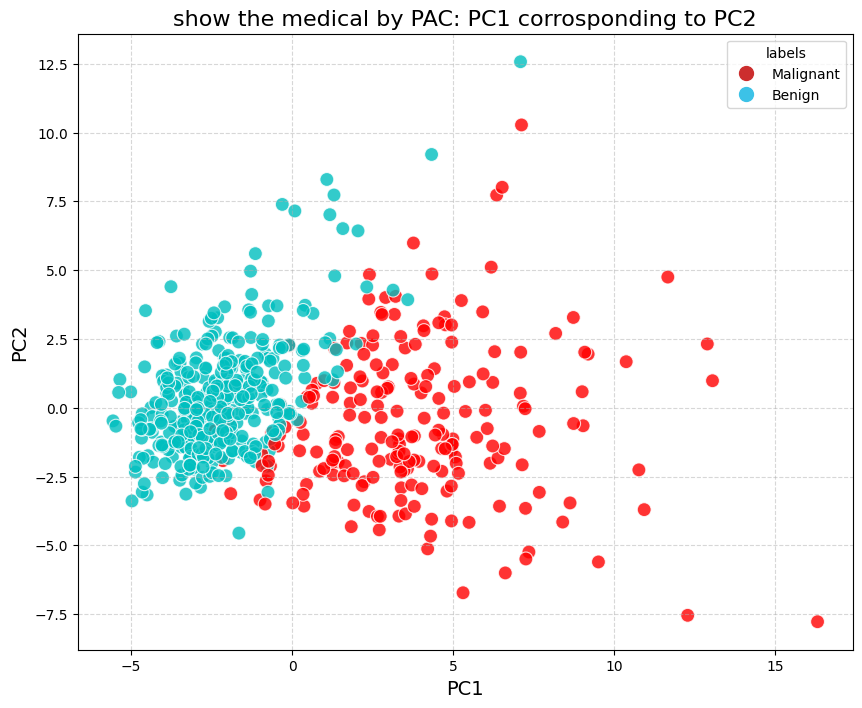

In [6]:
#visualize the PCA result:
plt.figure(figsize=(10, 8))
# Scatter Plot:
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='target',
    palette=["r","c" ],
    data=df_pca,
    alpha=0.8,
    s=100
)

plt.title('show the medical by PAC: PC1 corrosponding to PC2', fontsize=16)
plt.xlabel('PC1', fontsize=14)
plt.ylabel('PC2', fontsize=14)
COLORS = ["#cc2e2e", "#3cc2e7"]
LABELS = ['Malignant', 'Benign']
legend_handles = [mlines.Line2D([], [], color=c, marker='o', linestyle='', markersize=10)
                  for c in COLORS]
plt.legend(
    handles=legend_handles,
    labels=LABELS,
    title='labels'
)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [7]:
# How much variance is explained:
explained_variance_ratio = pca.explained_variance_ratio_

print(f"PCA1: {explained_variance_ratio[0]*100:.2f}%")
print(f" PCA2: {explained_variance_ratio[1]*100:.2f}%")
print(f"PC1 & PC2: {explained_variance_ratio.sum()*100:.2f}%")

PCA1: 44.27%
 PCA2: 18.97%
PC1 & PC2: 63.24%


In [8]:
# Feature Loadings:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=cancer['feature_names'])

print(" The high features on PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

print("\ The high features on PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

 The high features on PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64
\ The high features on PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
Name: PC2, dtype: float64


<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipython-input-3392647045.py:7: SyntaxWarning: invalid escape sequence '\ '
  print("\ The high features on PC2:")


## 3D PCA Projection
When extending the PCA to three components, the explained variance increased to around **70%**, offering a more faithful representation of the data structure. The 3D visualization provides a better spatial separation between the two classes, confirming that adding a third dimension helps recover more diagnostic information.


In [9]:

# Reduce the diamentions to 3 by PAC
pca_3d = PCA(n_components=3)
# Apply PCA to the scaled data
X_pca_3d = pca_3d.fit_transform(x_scaled)

pca_df_3d = pd.DataFrame(data = X_pca_3d, columns = ['PC1', 'PC2', 'PC3'])

pca_df_3d['Target'] = y
pca_df_3d['Diagnosis'] = pca_df_3d['Target'].apply(lambda x: 'Malignant ' if x == 0 else 'Benign ')

# visiualize the explained variance for 3D PCA
explained_variance_ratio_3d = pca_3d.explained_variance_ratio_
print(f"The explained variance PC1, PC2, PC3: {explained_variance_ratio_3d.sum()*100:.2f}%")

The explained variance PC1, PC2, PC3: 72.64%


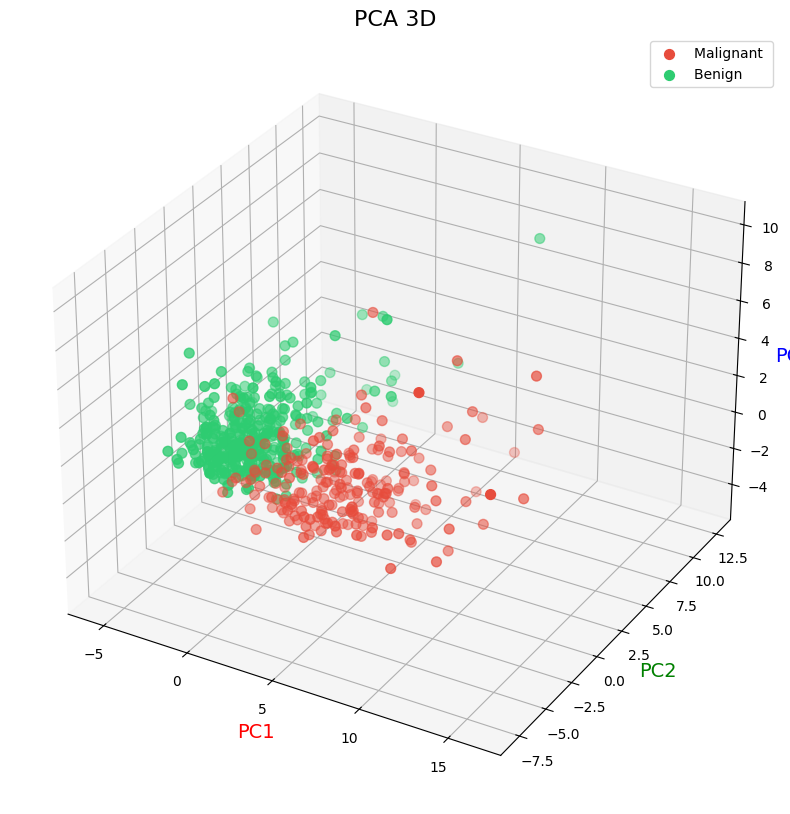

In [10]:
# 3D Visualization

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#2ecc71']

for target, color in zip([0, 1], colors):
    indicesToKeep = pca_df_3d['Target'] == target
    ax.scatter(pca_df_3d.loc[indicesToKeep, 'PC1'],
               pca_df_3d.loc[indicesToKeep, 'PC2'],
               pca_df_3d.loc[indicesToKeep, 'PC3'],
               c = color,
               s = 50,
               label = 'Malignant ' if target == 0 else 'Benign ')

# labels and title:
ax.set_xlabel('PC1', fontsize=14, color='red')
ax.set_ylabel('PC2', fontsize=14, color='green')
ax.set_zlabel('PC3', fontsize=14, color='blue')
ax.set_title('PCA 3D', fontsize=16)
ax.legend(loc='upper right')
plt.show()